# 多元线性回归
我们上一章介绍了单变量线性回归模型，接下来我们将扩展到多变量线性回归模型。多变量线性回归模型用于预测一个连续的目标变量与多个自变量之间的关系。多变量线性回归模型的数学表达式可以表示为：
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + ε $$
其中：
- $y$ 是目标变量 , 我们要预测的值。
- $x_1, x_2, ..., x_n$ 是自变量 , 用于预测目标变量的特征。
- $\beta_0$ 是截距项 , 当所有自变量都为零时，目标变量的预测值。
- $\beta_1, \beta_2, ..., \beta_n$ 是模型参数 , 在其他特征不变的情况下，$x_i$ 每变化一个单位，目标变量 $y$ 的预测值变化 $\beta_i$ 个单位。
- $\epsilon$ 是误差项 , 模型无法解释的异常波动

-----

## 多元线性回归的训练
多元线性回归模型的训练过程与单变量线性回归类似 , 找到一组最优的回归系数 ($\beta_0, \beta_1, ..., \beta_n$) 使得模型对训练数据的预测误差最小化。这个过程通常通过 **最小二乘法** 来实现

### 目标 : 最小化以下损失函数 
我们使用残差平方和（RSS）作为损失函数：
$$RSS = \sum_{i=1}^{m} (y_i - \hat{y_i})^2$$
其中：
- $m$ 是训练样本的数量
- $y_i$ 是第 $i$ 个训练样本的真实值
- $\hat{y_i}$ 是第 $i$ 个训练样本的预测值

训练的目标是找到一组回归系数，使得 RSS 最小化。

### 求解过程(矩阵形式)
当特征数量较多时，我们可以使用矩阵形式来表示和求解多元线性回归模型。设 $X$ 是一个 $m \times (n+1)$ 的矩阵，其中第一列是全 1（对应截距项），后面 $n$ 列是自变量的值；$\beta$ 是一个 $(n+1) \times 1$ 的参数向量；$Y$ 是一个 $m \times 1$ 的目标变量向量。多元线性回归模型可以表示为：
$$Y = X\beta + \epsilon$$

其中:
$$X = \begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1n} \\
1 & x_{21} & x_{22} & \cdots & x_{2n} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{m1} & x_{m2} & \cdots & x_{mn}
\end{bmatrix}, \quad
\beta = \begin{bmatrix}
\beta_0 \\
\beta_1 \\
\vdots \\
\beta_n
\end{bmatrix}, \quad
Y = \begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_m
\end{bmatrix}
$$


最小化 RSS 的目标可以通过求解以下正规方程来实现：
$$\beta = (X^T X)^{-1} X^T Y$$
其中 $X^T$ 是矩阵 $X$ 的转置，$(X^T X)^{-1}$ 是矩阵 $X^T X$ 的逆矩阵。

我们通常使用数值优化库(入 scikit-learn) 来高效 , 稳定地求解回归系数，尤其当特征数量较多时。

-----

## 使用 python 实现多元线性回归

In [13]:
# 1. 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing           # 一个经典的多变量数据集


# 加载数据集
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target           # 添加目标变量 : 房价中位数

print("数据集形状:", df.shape)
print("\n前五行数据:")
print(df.head())
print("\n特征说明")
print(california.DESCR[:500])  # 打印数据集描述的前 500 字符

数据集形状: (20640, 9)

前五行数据:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

特征说明
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block grou

In [14]:
# 2. 数据探索与预处理
print(df.info())
print("\n描述性统计:")
print(df.describe())


# 划分特征(X) 和目标变量(y)
X = df.drop('MedHouseVal', axis=1)  # 特征矩阵 : 包含除房价外的所有列
y = df['MedHouseVal']                 # 目标变量 : 房价中位数


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n训练集样本数: {X_train.shape[0]}")
print(f"测试集样本数: {X_test.shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

描述性统计:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333

In [15]:
# 3. 创建 , 训练 与 评估模型
model = LinearRegression()

# 训练模型
model.fit(X_train, y_train)

# 预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 评估模型性能
# 计算均方误差 (MSE) - 越小越好 
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

# 计算 R² 分数 - 越接近 1 越好
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("=== 模型评估结果 ===")
print(f"训练集 MSE: {mse_train}")
print(f"测试集 MSE: {mse_test}")
print(f"训练集 R²: {r2_train}")
print(f"测试集 R²: {r2_test}")

# 查看学到的模型参数
print("\n模型参数 (回归系数):")
print(f"截距 : {model.intercept_}")
print(f"回归系数 : {model.coef_}")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef}")

=== 模型评估结果 ===
训练集 MSE: 0.51793312552467
测试集 MSE: 0.5558915986952442
训练集 R²: 0.612551191396695
测试集 R²: 0.575787706032451

模型参数 (回归系数):
截距 : -37.02327770606412
回归系数 : [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
  MedInc: 0.4486749096657177
  HouseAge: 0.009724257517905028
  AveRooms: -0.1233233428279594
  AveBedrms: 0.783144906792974
  Population: -2.029620580105133e-06
  AveOccup: -0.003526318487134195
  Latitude: -0.4197924865883594
  Longitude: -0.43370806496398695


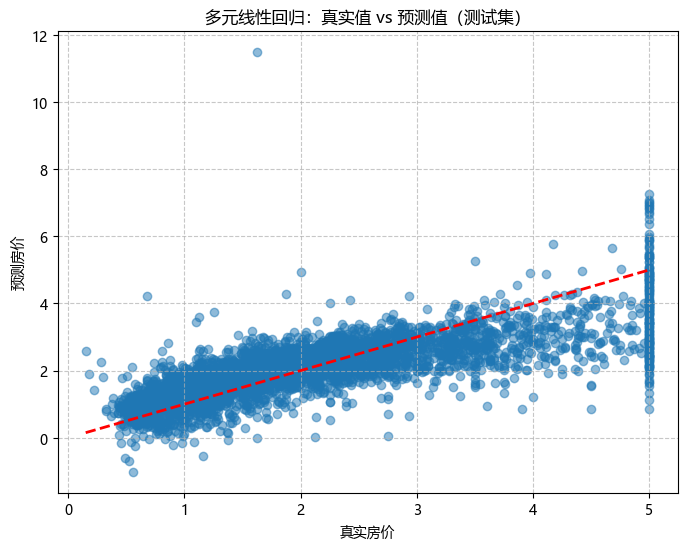

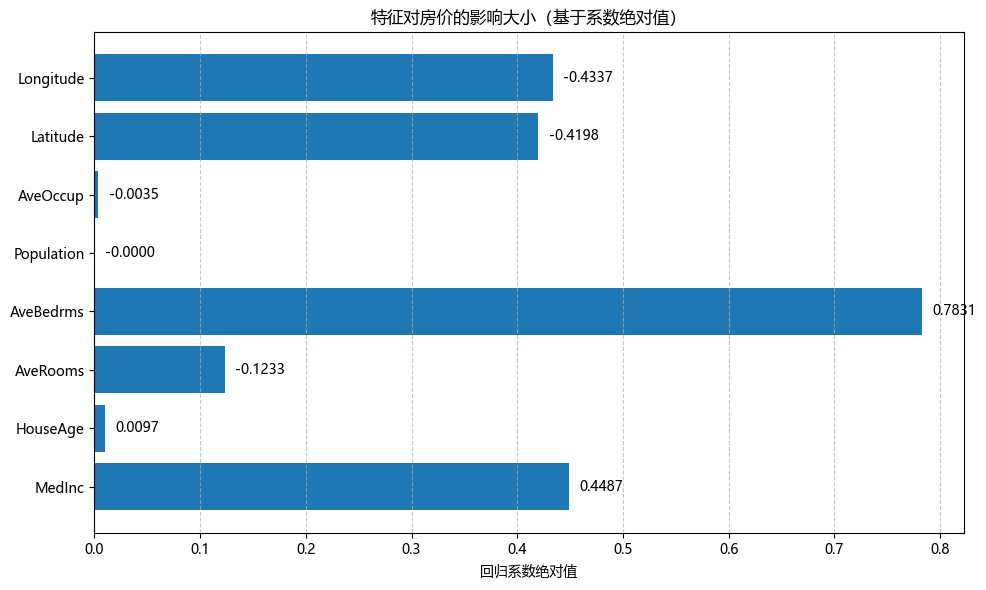

In [16]:
# 4. 可视化：真实值 vs 预测值 (测试集)
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # 绘制理想对角线
plt.xlabel('真实房价')
plt.ylabel('预测房价')
plt.title('多元线性回归：真实值 vs 预测值（测试集）')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 可视化：特征重要性（通过系数绝对值大小近似表示）
features = X.columns
coefs = model.coef_
plt.figure(figsize=(10, 6))
bars = plt.barh(features, np.abs(coefs)) # 使用绝对值比较影响大小
plt.xlabel('回归系数绝对值')
plt.title('特征对房价的影响大小（基于系数绝对值）')
# 为条形图添加数值标签
for bar, coef in zip(bars, coefs):
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{coef:.4f}', va='center')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

-----

## 多元线性回归的注意事项与挑战

### 关键假设
- 1. 线性关系 : 目标变量与自变量之间存在线性关系。
- 2. 独立性 : 训练样本之间相互独立。
- 3. 同方差性 : 误差项的方差在所有自变量的取值下保持恒定。
- 4. 正态性 : 误差服从正态分布。
- 5. 无多重共线性 : 自变量之间不应存在高度相关性。

### 挑战与应对

| 挑战 | 描述 | 可能后果 | 应对方法 |
|------|------| ------|------|
| 多重共线性 | 自变量之间存在高度相关性 | 系数估计不稳定 , 难以解释单个特征的影响 | 1.使用相关性矩阵检查并移除高相关特征 <br> 2使用主成分分析(PCA) 降维 <br> 3.使用正则化方法（如Ridge回归、Lasso回归） |
| 异方差性 | 误差的方差随自变量变化 | 参数估计不准确 | 1.使用加权最小二乘法或稳健标准误 |
| 异常值 | 存在偏离正常范围的观测值 | 影响模型拟合效果 | 1.使用鲁棒回归方法或进行异常值检测和处理 |
| 非线性关系 | 自变量与目标变量之间存在非线性关系 | 模型拟合效果不佳 | 1.考虑特征工程，引入多项式特征或对数变换 <br> 2.使用非线性模型(如决策树、神经网络) |
|过拟合|模型过于复杂，完美拟合训练数据噪声，在测试集上表现差。|测试集误差远大于训练集误差。|1. 收集更多数据。<br> 2. 使用更少的特征（特征选择）。<br> 3. 使用正则化。|